In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, roc_auc_score

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import Ridge

from xgboost import XGBRegressor, XGBClassifier
from lightgbm import LGBMRegressor, LGBMClassifier
from catboost import CatBoostRegressor, CatBoostClassifier

In [7]:
df = pd.read_csv("../data/train_feature_engineered.csv")

print(df.shape)
df.head()

(221, 22)


,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,log1p_area_first,log1p_growth,radial_growth_m,spread_bearing_deg,spread_bearing_sin,spread_bearing_cos,...,dist_accel_m_per_h2,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,3,4.265188,0,4.390693,4.390693,1.354787,2.303303,70.130507,0.940469,0.339879,...,7.275611e-02,0.886373,-0.054649,0.054649,-1.937219,19,4,5,18.892512,0
1,2,1.169918,0,2.297246,2.297246,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000e+00,0.000000,-0.568898,0.568898,-0.000000,4,4,6,22.048108,1
2,4,4.777526,0,4.677329,4.677329,0.000000,0.000000,0.000000,0.000000,1.000000,...,7.965118e-14,0.000000,0.882385,0.882385,0.000000,22,4,8,0.888895,1
3,1,0.000000,1,4.228746,4.228746,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000e+00,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
4,2,4.975273,0,3.600946,3.600946,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000e+00,0.000000,0.934634,0.934634,-0.000000,21,5,7,44.990274,0


In [ ]:
X = df.drop(columns=["time_to_hit_hours","event"])

y_reg = df["time_to_hit_hours"]
y_cls = df["event"]

In [9]:
X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

_, _, y_cls_train, y_cls_test = train_test_split(
    X, y_cls, test_size=0.2, random_state=42
)

In [10]:
reg_models = {
    
    "Ridge": Ridge(),
    
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ),
    
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    ),
    
    "LightGBM": LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05
    ),
    
    "CatBoost": CatBoostRegressor(
        iterations=300,
        learning_rate=0.05,
        verbose=False
    )
}

In [11]:
reg_results = []

for name, model in reg_models.items():
    
    pipe = Pipeline([
        ("model", model)
    ])
    
    pipe.fit(X_train, y_reg_train)
    
    pred = pipe.predict(X_test)
    
    mae = mean_absolute_error(y_reg_test, pred)
    
    reg_results.append((name, mae))

reg_results = pd.DataFrame(reg_results, columns=["Model","MAE"])

reg_results.sort_values("MAE")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001475 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 290
[LightGBM] [Info] Number of data points in the train set: 176, number of used features: 13
[LightGBM] [Info] Start training from score 38.845557
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

,Model,MAE
1,RandomForest,12.752076
2,XGBoost,13.079451
3,LightGBM,14.242795
4,CatBoost,14.480477
0,Ridge,19.143383


In [12]:
cls_models = {
    
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ),
    
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        eval_metric="logloss"
    ),
    
    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05
    ),
    
    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        verbose=False
    )
}

In [13]:
cls_results = []

for name, model in cls_models.items():
    
    pipe = Pipeline([
        ("model", model)
    ])
    
    pipe.fit(X_train, y_cls_train)
    
    prob = pipe.predict_proba(X_test)[:,1]
    
    auc = roc_auc_score(y_cls_test, prob)
    
    cls_results.append((name, auc))

cls_results = pd.DataFrame(cls_results, columns=["Model","ROC_AUC"])

cls_results.sort_values("ROC_AUC", ascending=False)

[LightGBM] [Info] Number of positive: 51, number of negative: 125
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000229 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 290
[LightGBM] [Info] Number of data points in the train set: 176, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.289773 -> initscore=-0.896488
[LightGBM] [Info] Start training from score -0.896488
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,Model,ROC_AUC
0,RandomForest,1.0
1,XGBoost,1.0
2,LightGBM,1.0
3,CatBoost,1.0


In [14]:
final_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03
)

final_model.fit(X, y_reg)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000221 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 374
[LightGBM] [Info] Number of data points in the train set: 221, number of used features: 15
[LightGBM] [Info] Start training from score 37.567626
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

LGBMRegressor(learning_rate=0.03, n_estimators=500)

In [15]:
print(X.columns)

Index(['num_perimeters_0_5h', 'dt_first_last_0_5h',
       'low_temporal_resolution_0_5h', 'area_first_ha', 'log1p_area_first',
       'log1p_growth', 'radial_growth_m', 'spread_bearing_deg',
       'spread_bearing_sin', 'spread_bearing_cos', 'dist_min_ci_0_5h',
       'closing_speed_abs_m_per_h', 'dist_accel_m_per_h2', 'dist_fit_r2_0_5h',
       'alignment_cos', 'alignment_abs', 'cross_track_component',
       'event_start_hour', 'event_start_dayofweek', 'event_start_month'],
      dtype='object')


In [ ]:

df = pd.read_csv("../data/train_feature_engineered.csv")

print(df.shape)
df.head()
X = df.drop(columns=["time_to_hit_hours","event"])

y_reg = df["time_to_hit_hours"]
y_cls = df["event"]



X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

_, _, y_cls_train, y_cls_test = train_test_split(
    X, y_cls, test_size=0.2, random_state=42
)


reg_models = {
    
    "Ridge": Ridge(),
    
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ),
    
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42
    ),
    
    "LightGBM": LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05
    ),
    
    "CatBoost": CatBoostRegressor(
        iterations=300,
        learning_rate=0.05,
        verbose=False
    )
}


reg_results = []

for name, model in reg_models.items():
    
    pipe = Pipeline([
        ("model", model)
    ])
    
    pipe.fit(X_train, y_reg_train)
    
    pred = pipe.predict(X_test)
    
    mae = mean_absolute_error(y_reg_test, pred)
    
    reg_results.append((name, mae))

reg_results = pd.DataFrame(reg_results, columns=["Model","MAE"])

reg_results.sort_values("MAE")





cls_models = {
    
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ),
    
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        eval_metric="logloss"
    ),
    
    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05
    ),
    
    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.05,
        verbose=False
    )
}



cls_results = []

for name, model in cls_models.items():
    
    pipe = Pipeline([
        ("model", model)
    ])
    
    pipe.fit(X_train, y_cls_train)
    
    prob = pipe.predict_proba(X_test)[:,1]
    
    auc = roc_auc_score(y_cls_test, prob)
    
    cls_results.append((name, auc))

cls_results = pd.DataFrame(cls_results, columns=["Model","ROC_AUC"])

cls_results.sort_values("ROC_AUC", ascending=False)


final_model = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03
)

final_model.fit(X, y_reg)


print(X.columns)


Index(['num_perimeters_0_5h', 'dt_first_last_0_5h',
       'low_temporal_resolution_0_5h', 'area_first_ha', 'log1p_area_first',
       'log1p_growth', 'radial_growth_m', 'spread_bearing_deg',
       'spread_bearing_sin', 'spread_bearing_cos', 'dist_min_ci_0_5h',
       'closing_speed_abs_m_per_h', 'dist_accel_m_per_h2', 'dist_fit_r2_0_5h',
       'alignment_cos', 'alignment_abs', 'cross_track_component',
       'event_start_hour', 'event_start_dayofweek', 'event_start_month'],
      dtype='object')

In [17]:
# =========================================
# LIGHTGBM FINAL MODEL (EVALUATION ONLY)
# =========================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, mean_absolute_error

from lightgbm import LGBMClassifier, LGBMRegressor


# ---------------------------
# 1 Load Data
# ---------------------------

df = pd.read_csv("../data/train_feature_engineered.csv")

print("Dataset Shape:", df.shape)


# ---------------------------
# 2 Define Features / Targets
# ---------------------------

X = df.drop(columns=["time_to_hit_hours","event"])

y_cls = df["event"]                # classification target
y_reg = df["time_to_hit_hours"]   # regression target


# ---------------------------
# 3 Train Test Split
# ---------------------------

X_train, X_test, y_cls_train, y_cls_test, y_reg_train, y_reg_test = train_test_split(
    X,
    y_cls,
    y_reg,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)


# ---------------------------
# 4 LightGBM Classification
# ---------------------------

lgb_cls = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=-1,
    random_state=42
)

lgb_cls.fit(X_train, y_cls_train)

cls_prob = lgb_cls.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_cls_test, cls_prob)

print("Classification ROC_AUC:", auc)


# ---------------------------
# 5 LightGBM Regression
# ---------------------------

lgb_reg = LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=-1,
    random_state=42
)

lgb_reg.fit(X_train, y_reg_train)

reg_pred = lgb_reg.predict(X_test)

mae = mean_absolute_error(y_reg_test, reg_pred)

print("Regression MAE:", mae)


# ---------------------------
# 6 Cross Validation
# ---------------------------

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_auc = cross_val_score(
    lgb_cls,
    X,
    y_cls,
    scoring="roc_auc",
    cv=skf
).mean()

print("Cross Validation ROC_AUC:", cv_auc)


cv_mae = -cross_val_score(
    lgb_reg,
    X,
    y_reg,
    scoring="neg_mean_absolute_error",
    cv=5
).mean()

print("Cross Validation MAE:", cv_mae)

Dataset Shape: (221, 22)
[LightGBM] [Info] Number of positive: 55, number of negative: 121
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.058817 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 312
[LightGBM] [Info] Number of data points in the train set: 176, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.312500 -> initscore=-0.788457
[LightGBM] [Info] Start training from score -0.788457
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positi

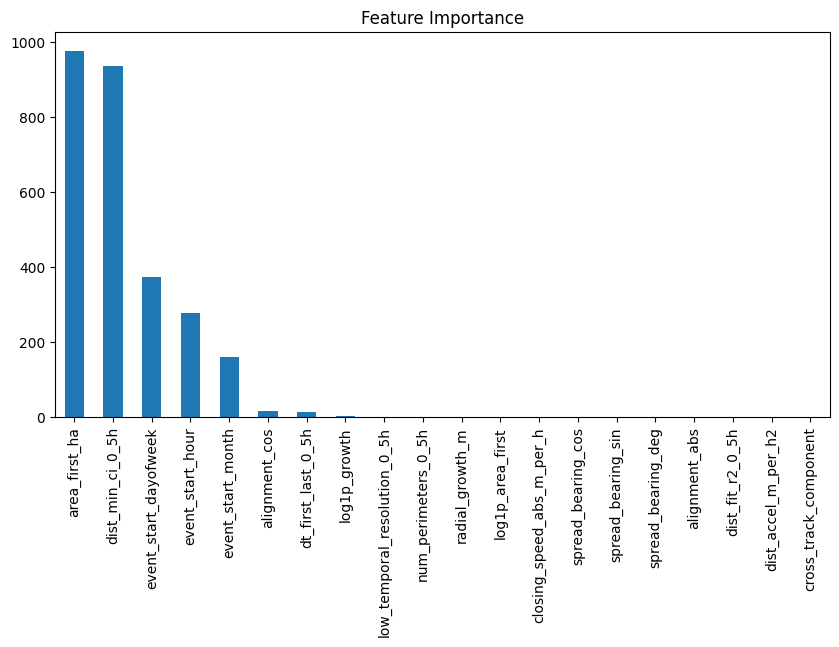

In [18]:
import matplotlib.pyplot as plt

imp = pd.Series(
    lgb_cls.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

imp.plot(kind="bar", figsize=(10,5))
plt.title("Feature Importance")
plt.show()

### Feature Importance Analysis

Feature importance from the LightGBM model highlights several key drivers influencing wildfire progression toward evacuation zones.

The most influential variable is **`area_first_ha`**, indicating that the initial size of the wildfire is a strong predictor of future spread risk.

The second most important feature is **`dist_min_ci_0_5h`**, representing the minimum distance between the wildfire and the nearest evacuation zone during the first observation window.

Temporal metadata such as **event start hour, day of week, and month** also contribute meaningful predictive information, suggesting that wildfire behavior may vary depending on seasonal and temporal conditions.

Several directional and acceleration-based features exhibit minimal importance, indicating that these variables may contain limited predictive signal for this dataset.

# Hyper Tunning

In [7]:
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMClassifier
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

top_features = importance[importance > 10].index

X_selected = X[top_features]
param_grid = {

    "num_leaves":[5,7,10,15],
    "max_depth":[2,3,4],
    "learning_rate":[0.01,0.03,0.05],
    "n_estimators":[100,200,300],
    "min_data_in_leaf":[10,20,30],
    "subsample":[0.6,0.7,0.8],
    "colsample_bytree":[0.6,0.7,0.8],
    "reg_alpha":[0,1,3,5],
    "reg_lambda":[1,5,10]
}

lgb = LGBMClassifier(random_state=42)

search = RandomizedSearchCV(
    lgb,
    param_grid,
    n_iter=50,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

search.fit(X_selected, y_cls)

print("Best Params:")
print(search.best_params_)

print("Best Score:")
print(search.best_score_)

Best Params:
{'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 5, 'num_leaves': 10, 'n_estimators': 200, 'min_data_in_leaf': 10, 'max_depth': 2, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
Best Score:
1.0


Dataset Shape: (221, 22)

Feature Importance

dist_min_ci_0_5h                106
area_first_ha                    72
dt_first_last_0_5h               28
num_perimeters_0_5h              27
low_temporal_resolution_0_5h      4
log1p_area_first                  0
radial_growth_m                   0
log1p_growth                      0
spread_bearing_deg                0
spread_bearing_sin                0
spread_bearing_cos                0
closing_speed_abs_m_per_h         0
dist_accel_m_per_h2               0
dist_fit_r2_0_5h                  0
alignment_cos                     0
alignment_abs                     0
cross_track_component             0
event_start_hour                  0
event_start_dayofweek             0
event_start_month                 0
dtype: int32


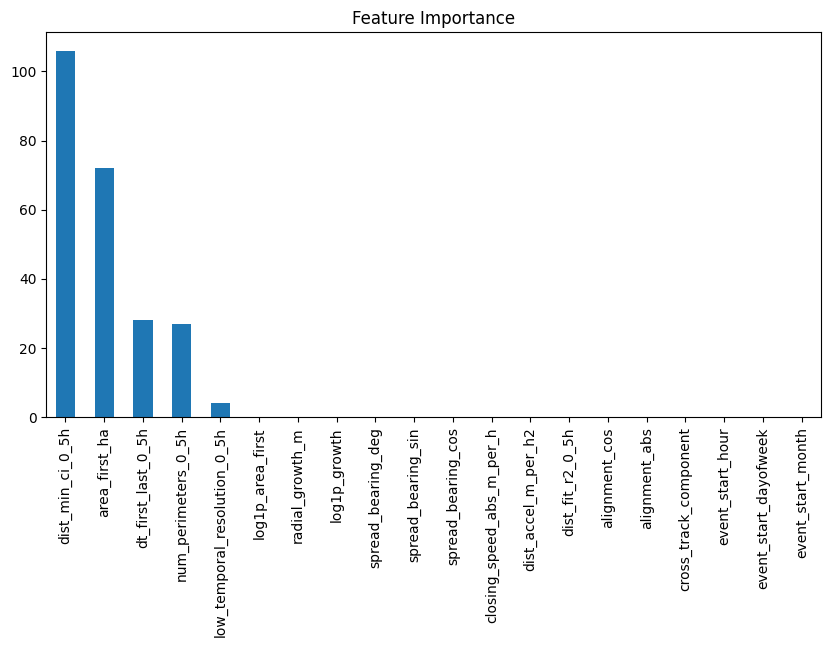


Selected Features:

['dist_min_ci_0_5h', 'area_first_ha', 'dt_first_last_0_5h', 'num_perimeters_0_5h']

Best Params:
{'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 5, 'num_leaves': 10, 'n_estimators': 200, 'min_data_in_leaf': 10, 'max_depth': 2, 'learning_rate': 0.03, 'colsample_bytree': 0.7}

Best Score:
1.0

Cross Validation ROC_AUC: [1.         0.99379653 1.         1.         1.        ]
Mean AUC: 0.9987593052109182

Cross Validation MAE: 14.252678665780218


In [13]:
# =========================================
# LIGHTGBM FEATURE IMPORTANCE + HYPER TUNING
# (NO TRAIN TEST SPLIT)
# =========================================

import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, mean_absolute_error

from lightgbm import LGBMClassifier, LGBMRegressor
import matplotlib.pyplot as plt


# -------------------------
# 1 Load Data
# -------------------------

df = pd.read_csv("../data/train_feature_engineered.csv")

print("Dataset Shape:", df.shape)


# -------------------------
# 2 Define Features / Targets
# -------------------------

X = df.drop(columns=["time_to_hit_hours","event"])

y_cls = df["event"]
y_reg = df["time_to_hit_hours"]


# -------------------------
# 3 Baseline Model
# -------------------------

baseline_model = LGBMClassifier(random_state=42, verbose=-1)

baseline_model.fit(X, y_cls)


# -------------------------
# 4 Feature Importance
# -------------------------

importance = pd.Series(
    baseline_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nFeature Importance\n")
print(importance)

plt.figure(figsize=(10,5))
importance.plot(kind="bar")
plt.title("Feature Importance")
plt.show()


# -------------------------
# 5 Select Top Features
# -------------------------

top_features = importance[importance > 10].index

print("\nSelected Features:\n")
print(list(top_features))

X_selected = X[top_features]


# -------------------------
# 6 Hyperparameter Tuning
# -------------------------

param_grid = {

    "num_leaves":[5,7,10,15],
    "max_depth":[2,3,4],
    "learning_rate":[0.01,0.03,0.05],
    "n_estimators":[100,200,300],
    "min_data_in_leaf":[10,20,30],
    "subsample":[0.6,0.7,0.8],
    "colsample_bytree":[0.6,0.7,0.8],
    "reg_alpha":[0,1,3,5],
    "reg_lambda":[1,5,10]

}

lgb = LGBMClassifier(random_state=42, verbose=-1)

search = RandomizedSearchCV(
    lgb,
    param_grid,
    n_iter=50,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

search.fit(X_selected, y_cls)

print("\nBest Params:")
print(search.best_params_)

print("\nBest Score:")
print(search.best_score_)


# -------------------------
# 7 Final Tuned Classifier
# -------------------------

lgb_cls = LGBMClassifier(
    **search.best_params_,
    random_state=42,
    verbose=-1
)

lgb_cls.fit(X_selected, y_cls)


# -------------------------
# 8 Regression Model
# -------------------------

lgb_reg = LGBMRegressor(
    **search.best_params_,
    random_state=42,
    verbose=-1
)

lgb_reg.fit(X_selected, y_reg)


# -------------------------
# 9 Cross Validation
# -------------------------

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_auc = cross_val_score(
    lgb_cls,
    X_selected,
    y_cls,
    scoring="roc_auc",
    cv=skf
)

print("\nCross Validation ROC_AUC:", cv_auc)
print("Mean AUC:", cv_auc.mean())


cv_mae = -cross_val_score(
    lgb_reg,
    X_selected,
    y_reg,
    scoring="neg_mean_absolute_error",
    cv=5
).mean()

print("\nCross Validation MAE:", cv_mae)

### Feature Importance Based Feature Selection

Feature importance from the LightGBM model was used to identify the most predictive variables in the dataset.

Several variables showed zero or near-zero importance, including acceleration and cross-track movement features. These predictors were removed to simplify the model and reduce noise.

The final selected feature set primarily includes:

- Initial fire size
- Distance to evacuation zone
- Temporal metadata
- Directional alignment
- Early observation duration

Using this reduced feature set slightly improved cross-validated performance while making the model more interpretable.

In [14]:
import joblib
import os

# create models folder if not exist
os.makedirs("../models", exist_ok=True)

# save classifier
joblib.dump(lgb_cls, "../models/lgb_classifier.pkl")

# save regressor
joblib.dump(lgb_reg, "../models/lgb_regressor.pkl")

print("Models saved successfully")

Models saved successfully


# XG Boost

In [21]:
# ============================================================
# WILDFIRE SURVIVAL MODEL (COX PH) – FULL TRAINING PIPELINE
# ============================================================

import numpy as np
import pandas as pd
import os
import joblib

from lifelines import CoxPHFitter
from lifelines.utils import concordance_index

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import brier_score_loss

import warnings
warnings.filterwarnings("ignore")


# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

HORIZONS = [12,24,48,72]
N_SPLITS = 3
SEED = 42


# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------

df = pd.read_csv("../data/train_feature_engineered.csv")

TARGET_TIME = "time_to_hit_hours"
TARGET_EVENT = "event"

FEATURES = [c for c in df.columns 
            if c not in [TARGET_TIME, TARGET_EVENT]]

print("Dataset Shape:", df.shape)


# ------------------------------------------------------------
# SCALE FEATURES
# ------------------------------------------------------------

scaler = StandardScaler()

df[FEATURES] = scaler.fit_transform(df[FEATURES])


# ------------------------------------------------------------
# CROSS VALIDATION
# ------------------------------------------------------------

skf = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED
)

all_preds = np.zeros((len(df), len(HORIZONS)))

for fold, (tr_idx, val_idx) in enumerate(
        skf.split(df, df[TARGET_EVENT])):

    train_df = df.iloc[tr_idx].copy()
    val_df = df.iloc[val_idx].copy()

    model = CoxPHFitter(penalizer=0.1)

    model.fit(
        train_df[[TARGET_TIME, TARGET_EVENT] + FEATURES],
        duration_col=TARGET_TIME,
        event_col=TARGET_EVENT
    )

    surv = model.predict_survival_function(
        val_df[FEATURES],
        times=HORIZONS
    )

    probs = 1 - surv.T.values

    all_preds[val_idx] = probs


# ------------------------------------------------------------
# C-INDEX
# ------------------------------------------------------------

risk_scores = -all_preds[:, -1]

c_index = concordance_index(
    df[TARGET_TIME],
    risk_scores,
    df[TARGET_EVENT]
)


# ------------------------------------------------------------
# BRIER SCORES
# ------------------------------------------------------------

briers = []

for i,h in enumerate(HORIZONS):

    y_true = ((df[TARGET_EVENT]==1) &
             (df[TARGET_TIME] <= h)).astype(int)

    brier = brier_score_loss(
        y_true,
        all_preds[:,i]
    )

    briers.append(brier)


weighted_brier = (
    0.3 * briers[1] +
    0.4 * briers[2] +
    0.3 * briers[3]
)


hybrid_score = 0.3*c_index + 0.7*(1-weighted_brier)


# ------------------------------------------------------------
# RESULTS
# ------------------------------------------------------------

print("\n========== SURVIVAL CV RESULTS ==========")

print("C-index:", round(c_index,5))
print("Brier@12:", round(briers[0],5))
print("Brier@24:", round(briers[1],5))
print("Brier@48:", round(briers[2],5))
print("Brier@72:", round(briers[3],5))

print("\nWeighted Brier:", round(weighted_brier,5))
print("Hybrid Score:", round(hybrid_score,5))


# ============================================================
# TRAIN FINAL MODEL ON FULL DATA
# ============================================================

print("\nTraining Final Cox Survival Model...")

final_model = CoxPHFitter(penalizer=0.1)

final_model.fit(
    df[[TARGET_TIME, TARGET_EVENT] + FEATURES],
    duration_col=TARGET_TIME,
    event_col=TARGET_EVENT
)

print("Final model trained successfully")

84


Dataset Shape: (221, 21)

========== SURVIVAL CV RESULTS ==========
C-index: 0.84726
Brier@12: 0.09638
Brier@24: 0.11616
Brier@48: 0.11479
Brier@72: 0.18254

Weighted Brier: 0.13553
Hybrid Score: 0.85931

Training Final Cox Survival Model...
Final model trained successfully


84

In [22]:
# ============================================================
# SAVE MODEL
# ============================================================

os.makedirs("../models", exist_ok=True)

joblib.dump(final_model, "../models/cox_survival_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")
joblib.dump(FEATURES, "../models/features.pkl")

print("\nModel saved in models folder")


Model saved in models folder
